In [1]:
import time

In [2]:
import os
import cv2
import numpy as np
from imutils import paths
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Key parameters
IMAGE_DIMS = (224, 224)  # MobileNetV2 expects 224x224
dataset_dir = "C:/Users/Souma Chakraborty/OneDrive/Desktop/ML_RESEARCH/Fruit And Vegetable Diseases Dataset"
ALLOWED_CLASSES = {"Potato__Healthy", "Potato__Rotten"}

# Custom Dataset class
class FruitDataset(Dataset):
    def __init__(self, imagePaths, labels, transform=None):
        self.imagePaths = imagePaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imagePaths)

    def __getitem__(self, idx):
        imagePath = self.imagePaths[idx]
        image = cv2.imread(imagePath)
        if image is None:
            raise ValueError(f"Failed to load image: {imagePath}")
        image = cv2.resize(image, IMAGE_DIMS)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype("float32") / 255.0
        if self.transform:
            image = self.transform(image)
        else:
            # Convert HWC to CHW tensor
            image = torch.from_numpy(image.transpose(2, 0, 1))
        label = self.labels[idx]
        return image, label

def load_data():
    data = []
    labels = []
    imagePaths = list(paths.list_images(dataset_dir))
    print(f"Found {len(imagePaths)} images in total.")
    for imagePath in imagePaths:
        label = imagePath.split(os.path.sep)[-2]
        if label not in ALLOWED_CLASSES:
            continue
        if cv2.imread(imagePath) is None:
            print(f"Failed to load image: {imagePath}")
            continue
        data.append(imagePath)
        labels.append(label)
    print(f"\nProcessed {len(data)} images")
    print(f"Unique labels found: {set(labels)}")
    if len(data) == 0:
        raise ValueError("No images were processed. Check your dataset directory and paths.")
    # Encode labels
    le = LabelEncoder()
    encoded_labels = le.fit_transform(labels)
    (trainPaths, testPaths, trainLabels, testLabels) = train_test_split(
        data, encoded_labels, test_size=0.20, random_state=42)
    return trainPaths, testPaths, trainLabels, testLabels, le

# Load data and create Dataset objects
trainPaths, testPaths, trainLabels, testLabels, le = load_data()

# (Optional) Use additional transforms if needed
transform = transforms.Compose([
    transforms.ToTensor()  # Converts image from HWC [0,1] to CHW tensor [0,1]
])

trainDataset = FruitDataset(trainPaths, trainLabels, transform=None)
testDataset = FruitDataset(testPaths, testLabels, transform=None)

# Create DataLoaders
BS = 32  # Batch size
trainLoader = DataLoader(trainDataset, batch_size=BS, shuffle=True, num_workers=0, drop_last=True)
testLoader = DataLoader(testDataset, batch_size=BS, shuffle=False, num_workers=0, drop_last=True)


Found 14770 images in total.

Processed 1198 images
Unique labels found: {'Potato__Healthy', 'Potato__Rotten'}


In [3]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torchvision.models as models

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained MobileNetV2 and modify its classifier for 2 classes
mobilenet = models.mobilenet_v2(pretrained=True)
# Optionally freeze feature extractor
for param in mobilenet.features.parameters():
    param.requires_grad = False

# Replace the classifier with a new one for 2 classes
num_features = mobilenet.classifier[1].in_features
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_features, len(le.classes_))
)
mobilenet = mobilenet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet.parameters(), lr=1e-4)

print(mobilenet)
print(f"Training MobileNetV2 on device: {device}")

# Training loop
EPOCHS = 20
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("[INFO] Training MobileNetV2 model...")
for epoch in range(EPOCHS):
    mobilenet.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    for images, labels in tqdm(trainLoader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        total += images.size(0)
    epoch_loss = running_loss / total
    epoch_acc = running_corrects.double() / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc.item())
    
    mobilenet.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = mobilenet(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_corrects += torch.sum(preds == labels.data)
            val_total += images.size(0)
    val_loss = val_running_loss / val_total
    val_acc = val_running_corrects.double() / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc.item())
    print(f"Epoch {epoch+1}/{EPOCHS}: Train loss {epoch_loss:.4f}, Train acc {epoch_acc:.4f}, Val loss {val_loss:.4f}, Val acc {val_acc:.4f}")

# FP32 evaluation function
def evaluate(model, dataloader, device_eval):
    model.to(device_eval)
    model.eval()
    all_preds = []
    all_labels = []
    total_time = 0.0
    total_samples = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device_eval)
            start = time.time()
            outputs = model(images)
            end = time.time()
            total_time += (end - start)
            total_samples += images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    avg_inference_time = (total_time / total_samples) * 1000  # ms per image
    return accuracy, avg_inference_time, all_preds, all_labels



c:\Users\Souma Chakraborty\OneDrive\Desktop\ML_RESEARCH\resenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Souma Chakraborty\OneDrive\Desktop\ML_RESEARCH\resenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

Epoch 1/20: 100%|██████████| 29/29 [00:17<00:00,  1.61it/s]


Epoch 1/20: Train loss 0.7120, Train acc 0.5119, Val loss 0.6564, Val acc 0.5804


Epoch 2/20: 100%|██████████| 29/29 [00:16<00:00,  1.78it/s]


...

Epoch 18/20: Train loss 0.2350, Train acc 0.9364, Val loss 0.2383, Val acc 0.9241


Epoch 19/20: 100%|██████████| 29/29 [00:17<00:00,  1.65it/s]


Epoch 19/20: Train loss 0.2169, Train acc 0.9450, Val loss 0.2342, Val acc 0.9241


Epoch 20/20: 100%|██████████| 29/29 [00:17<00:00,  1.63it/s]


Epoch 20/20: Train loss 0.2323, Train acc 0.9267, Val loss 0.2342, Val acc 0.9241


In [4]:
fp32_accuracy, fp32_inference_time, all_preds, all_labels = evaluate(mobilenet, testLoader, device)
print(f"MobileNetV2 FP32 - Accuracy: {fp32_accuracy:.4f}, Inference Time: {fp32_inference_time:.2f} ms/image")

MobileNetV2 FP32 - Accuracy: 0.9241, Inference Time: 13.28 ms/image


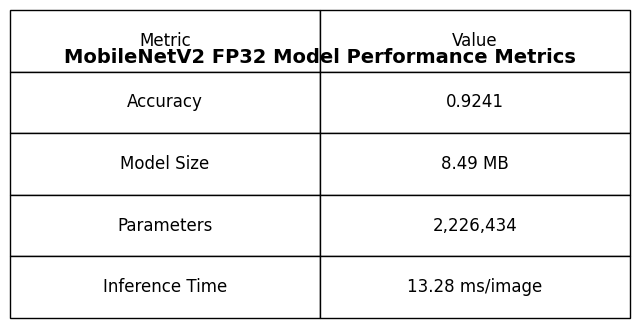

MobileNetV2 FP32 Model Classification Report:
              precision    recall  f1-score   support

     healthy       0.88      0.98      0.93       115
      rotten       0.98      0.86      0.92       109

    accuracy                           0.92       224
   macro avg       0.93      0.92      0.92       224
weighted avg       0.93      0.92      0.92       224



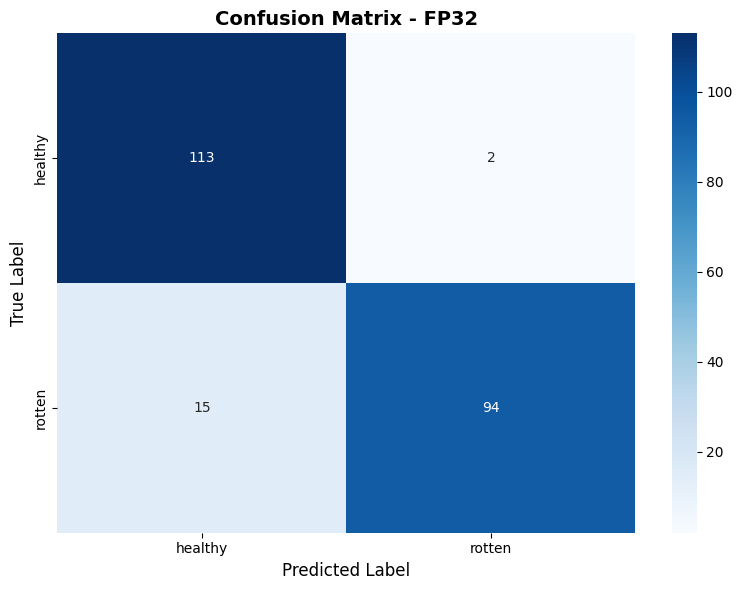

MobileNetV2 FP32 Model Confusion Matrix Accuracy: 0.9241


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------
# FP32 Model Performance Metrics
# -------------------------------
def create_model_performance_metrics_fp32(model, test_accuracy, inference_time):
    total_params = sum(p.numel() for p in model.parameters())
    model_size_mb = total_params * 4 / (1024 * 1024)  # 4 bytes per parameter
    metrics = {
        'Metric': ['Accuracy', 'Model Size', 'Parameters', 'Inference Time'],
        'Value': [f'{test_accuracy:.4f}', f'{model_size_mb:.2f} MB', f'{total_params:,}', f'{inference_time:.2f} ms/image']
    }
    metrics_df = pd.DataFrame(metrics)
    plt.figure(figsize=(8, 4))
    plt.axis('tight')
    plt.axis('off')
    table = plt.table(cellText=metrics_df.values,
                      colLabels=metrics_df.columns,
                      cellLoc='center',
                      loc='center',
                      bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)
    plt.title('MobileNetV2 FP32 Model Performance Metrics', fontsize=14, fontweight='bold', y=0.8)
    plt.show()
    return metrics_df

metrics_df_fp32 = create_model_performance_metrics_fp32(mobilenet, fp32_accuracy, fp32_inference_time)

# Simplify class names for display (healthy/rotten)
simple_class_names = [name.replace("Potato__Healthy", "healthy")
                      .replace("Potato__Rotten", "rotten")
                      for name in le.classes_]

# Print classification report for the FP32 model
report_fp32 = classification_report(all_labels, all_preds, target_names=simple_class_names)
print("MobileNetV2 FP32 Model Classification Report:")
print(report_fp32)

# Plot confusion matrix for the FP32 model
def plot_confusion_matrix_fp32(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - FP32', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    accuracy = np.trace(cm) / np.sum(cm)
    return accuracy

cm_accuracy_fp32 = plot_confusion_matrix_fp32(all_labels, all_preds, simple_class_names)
print(f"MobileNetV2 FP32 Model Confusion Matrix Accuracy: {cm_accuracy_fp32:.4f}")


[INFO] Generating training history plot...


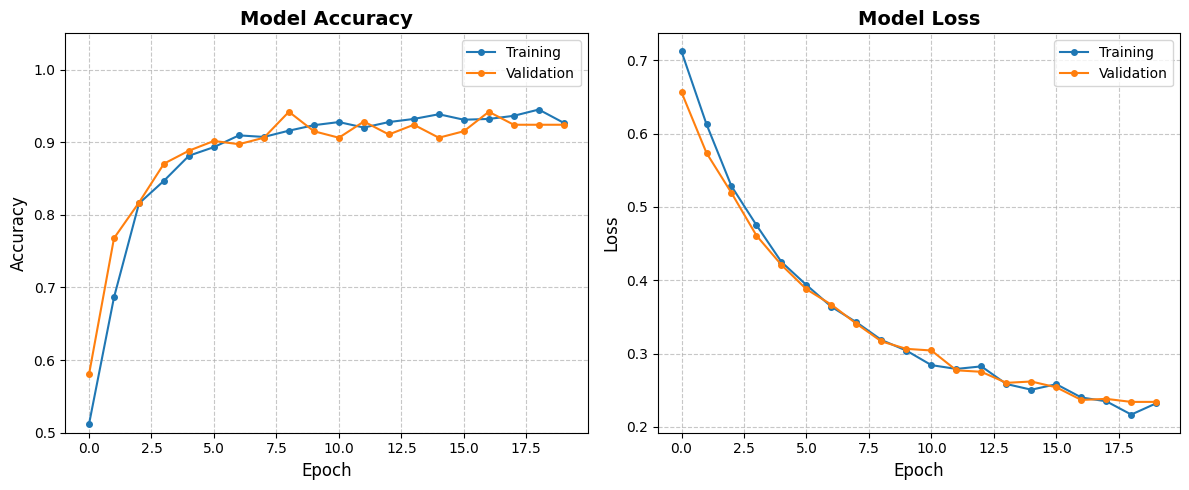

In [6]:
import matplotlib.pyplot as plt

# Plot training history for ResNet18
def plot_training_history(train_losses, val_losses, train_acc, val_acc):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_acc, marker='o', linestyle='-', markersize=4, label='Training')
    plt.plot(val_acc, marker='o', linestyle='-', markersize=4, label='Validation')
    plt.title('Model Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.ylim([0.5, 1.05])
    
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, marker='o', linestyle='-', markersize=4, label='Training')
    plt.plot(val_losses, marker='o', linestyle='-', markersize=4, label='Validation')
    plt.title('Model Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

print("[INFO] Generating training history plot...")
plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)
